# 🔧 Data Preprocessing & Augmentation

**Goal:** Prepare images for CNN training

**Tasks:**
1. Resize images to standard size (224×224)
2. Normalize pixel values (0-255 → 0-1)
3. Create data augmentation pipeline
4. Visualize preprocessed data

**Author:** Akakinad

In [1]:
# Core libraries
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Load the dataset
dataset, dataset_info = tfds.load(
    'oxford_flowers102',
    with_info=True,
    as_supervised=True
)

# Split into train, validation, test
train_set = dataset['train']
val_set = dataset['validation']
test_set = dataset['test']

print("✅ Dataset loaded")
print(f"Train: 1,020 | Validation: 1,020 | Test: 6,149")

✅ Dataset loaded
Train: 1,020 | Validation: 1,020 | Test: 6,149


In [3]:
# Standard image size for CNNs
IMAGE_SIZE = 224

print(f"Target image size: {IMAGE_SIZE}×{IMAGE_SIZE}")
print("Why 224? Most pre-trained models (ResNet, VGG) use this size")

Target image size: 224×224
Why 224? Most pre-trained models (ResNet, VGG) use this size


In [4]:
# Function to preprocess images
def preprocess_image(image, label):
    # Resize to 224x224
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    
    # Normalize pixel values from 0-255 to 0-1
    image = image / 255.0
    
    return image, label

print("✅ Preprocessing function created")

✅ Preprocessing function created


In [5]:
# Test preprocessing on one image
for original_image, label in train_set.take(1):
    preprocessed_image, _ = preprocess_image(original_image, label)
    
    print("BEFORE preprocessing:")
    print(f"  Shape: {original_image.shape}")
    print(f"  Pixel range: [{original_image.numpy().min()}, {original_image.numpy().max()}]")
    
    print("\nAFTER preprocessing:")
    print(f"  Shape: {preprocessed_image.shape}")
    print(f"  Pixel range: [{preprocessed_image.numpy().min():.3f}, {preprocessed_image.numpy().max():.3f}]")

BEFORE preprocessing:
  Shape: (500, 667, 3)
  Pixel range: [0, 255]

AFTER preprocessing:
  Shape: (224, 224, 3)
  Pixel range: [0.000, 0.991]


2026-02-18 15:11:10.522307: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-02-18 15:11:10.546499: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


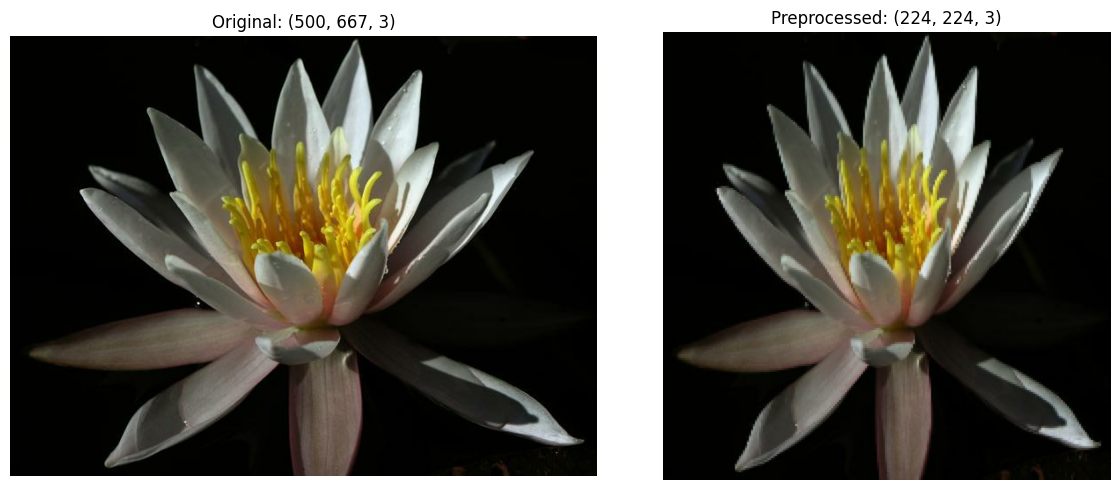

2026-02-18 15:17:53.302973: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
# Compare original vs preprocessed images
for original_image, label in train_set.take(1):
    preprocessed_image, _ = preprocess_image(original_image, label)
    
    plt.figure(figsize=(12, 5))
    
    # Original
    plt.subplot(1, 2, 1)
    plt.imshow(original_image.numpy().astype('uint8'))
    plt.title(f"Original: {original_image.shape}")
    plt.axis('off')
    
    # Preprocessed
    plt.subplot(1, 2, 2)
    plt.imshow(preprocessed_image.numpy())
    plt.title(f"Preprocessed: {preprocessed_image.shape}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [7]:
# Apply preprocessing to all datasets
train_processed = train_set.map(preprocess_image)
val_processed = val_set.map(preprocess_image)
test_processed = test_set.map(preprocess_image)

print("✅ Preprocessing applied to all datasets")
print("All images are now 224×224 with normalized pixels")

✅ Preprocessing applied to all datasets
All images are now 224×224 with normalized pixels


---

## 🎨 Data Augmentation

**Problem:** We only have ~10 images per flower class (very small!)

**Solution:** Create variations of existing images by:
- Rotating (slight angles)
- Flipping horizontally
- Zooming in/out
- Adjusting brightness

**Goal:** Make the model robust to different viewing conditions

In [8]:
# Create data augmentation function
def augment_image(image, label):
    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)
    
    # Random rotation (up to 20 degrees)
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    
    # Random brightness adjustment
    image = tf.image.random_brightness(image, max_delta=0.2)
    
    # Keep values in valid range [0, 1]
    image = tf.clip_by_value(image, 0.0, 1.0)
    
    return image, label

print("✅ Augmentation function created")

✅ Augmentation function created


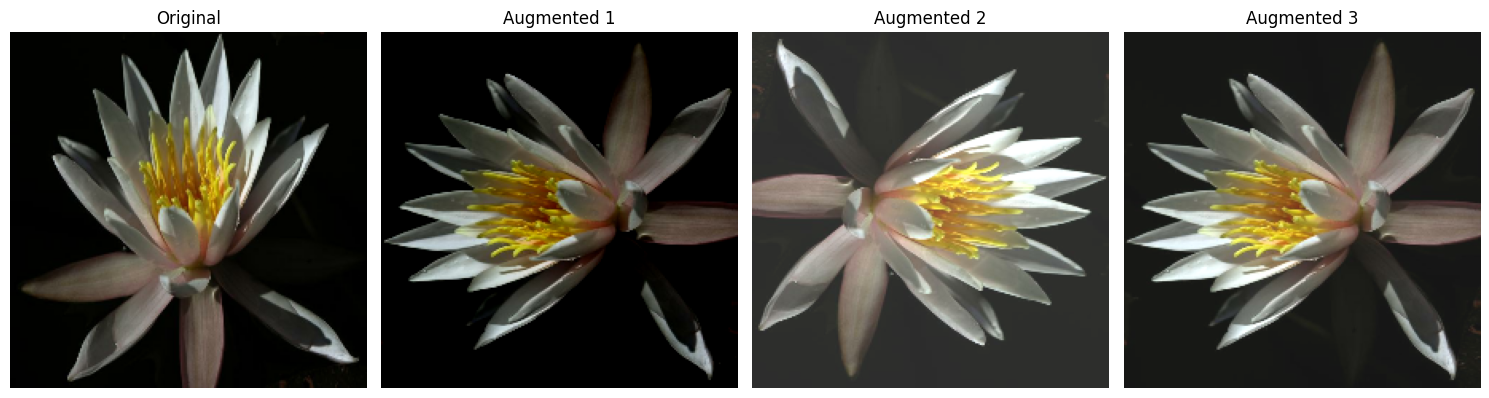

In [9]:
# Show the same flower with different augmentations
for original_image, label in train_processed.take(1):
    plt.figure(figsize=(15, 5))
    
    # Original
    plt.subplot(1, 4, 1)
    plt.imshow(original_image.numpy())
    plt.title("Original")
    plt.axis('off')
    
    # Show 3 augmented versions
    for i in range(3):
        augmented_image, _ = augment_image(original_image, label)
        plt.subplot(1, 4, i + 2)
        plt.imshow(augmented_image.numpy())
        plt.title(f"Augmented {i+1}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [10]:
# Apply augmentation ONLY to training data
train_augmented = train_processed.map(augment_image)

print("✅ Augmentation applied to training set")
print("Note: Validation and test sets are NOT augmented")
print("Why? We want to test on real, unmodified images")

✅ Augmentation applied to training set
Note: Validation and test sets are NOT augmented
Why? We want to test on real, unmodified images


In [11]:
# Set batch size
BATCH_SIZE = 32

print(f"Batch size: {BATCH_SIZE}")
print("What this means: The model will see 32 images at once during training")

Batch size: 32
What this means: The model will see 32 images at once during training


In [12]:
# Prepare training data with shuffling and batching
train_final = train_augmented.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Prepare validation and test data (no shuffling needed)
val_final = val_processed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_final = test_processed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("✅ Data pipeline ready for training!")
print(f"   - Training: shuffled + augmented + batched ({BATCH_SIZE})")
print(f"   - Validation: batched ({BATCH_SIZE})")
print(f"   - Test: batched ({BATCH_SIZE})")

✅ Data pipeline ready for training!
   - Training: shuffled + augmented + batched (32)
   - Validation: batched (32)
   - Test: batched (32)


---

## ✅ Preprocessing Complete!

**What we built:**
1. ✅ Resize function: All images → 224×224
2. ✅ Normalization: Pixels 0-255 → 0-1
3. ✅ Data augmentation: Flips, rotations, brightness
4. ✅ Batching: Groups of 32 images
5. ✅ Prefetching: Optimized loading

**Data ready for training:**
- Training: 1,020 images (augmented)
- Validation: 1,020 images  
- Test: 6,149 images

**Next notebook:** Building the CNN model